597 cells flagged for filtering out using attribute RNA_nCounts



461 cells flagged for filtering out using attribute RNA_nFeatures



612 cells flagged for filtering out using attribute RNA_percentMito



Calculating summary statistics



Using cached feature stats for cell_key I



Using existing corrected dispersion values



Calculating HVGs



500 genes marked as HVGs



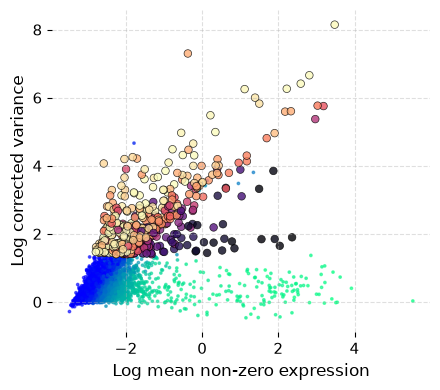

make_graph step 1/7: normalize expression matrix (computing)



make_graph step 1/7: normalize expression matrix finished in 0.6s (computing)



make_graph step 2/7: normalization statistics (computing)



make_graph step 2/7: normalization statistics finished in 0.0s (computing)



make_graph step 3/7: dimension reduction, ANN index, and kmeans (computing)



...

ANN recall: 99.80%



make_graph step 7/7: finalize graph metadata (computing)



make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)



make_graph finished in 12.7s (7/7 steps, 12.6s in logged steps)



Training UMAP:   0%|                                                                                          …

In [1]:
import scarf
import scarf.plotting as splt

scarf.fetch_dataset(
    "tenx_5K_pbmc_rnaseq",
    save_path="scarf_datasets",
    as_zarr=True,
)
ds = scarf.DataStore(
    "scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key="hvgs", k=11, dims=15, n_centroids=100)
ds.run_umap(n_epochs=150, spread=5, min_dist=1, parallel=True)
ds.run_leiden_clustering(resolution=0.5)

Training UMAP:   0%|                                                                                          …

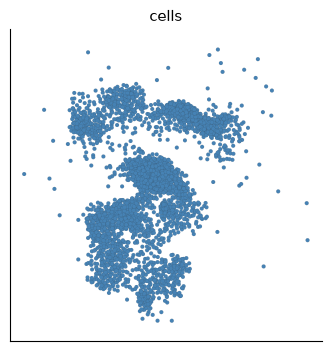

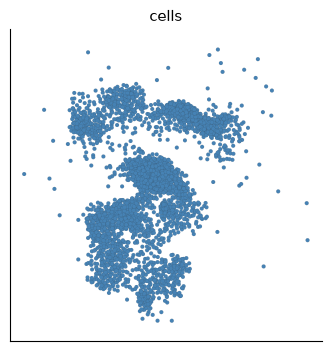

In [2]:
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
    use_density_map=True,
    label="densMAP",
)
splt.embedding(ds, layout_key="RNA_densMAP", show=False).figure

parallel=True is not supported by the sgtsnepi Python backend; running single-threaded



Number of vertices: 3940


Embedding dimensions: 2


Rescaling parameter λ: 1


Early exag. multiplier α: 10


...

Iteration 400: error is 2.78369 (50 iterations in 0.113927 seconds)


Iteration 450: error is 2.76323 (50 iterations in 0.104961 seconds)


Iteration 499: error is 2.75948 (50 iterations in 0.104374 seconds)


 --- Time spent in each module --- 



 Attractive forces: 0.173245 sec [21.6419%] |  Repulsive forces: 0.627261 sec [78.3581%]


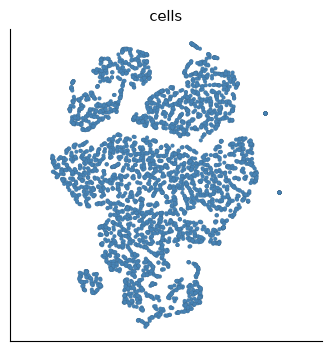

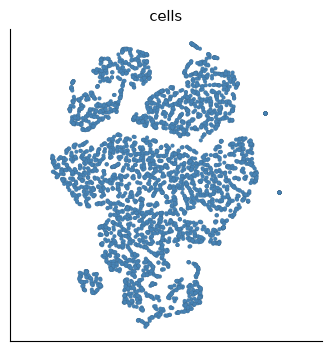

In [3]:
ds.run_tsne(
    alpha=10,
    box_h=1,
    early_iter=250,
    max_iter=500,
    parallel=True,
)
splt.embedding(ds, layout_key="RNA_tSNE", show=False).figure

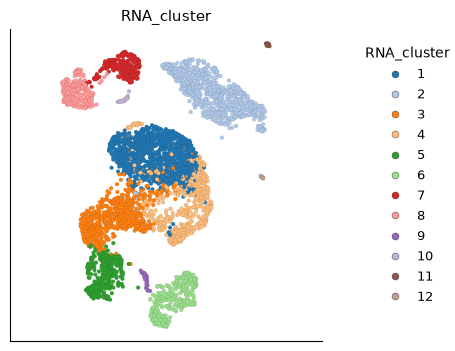

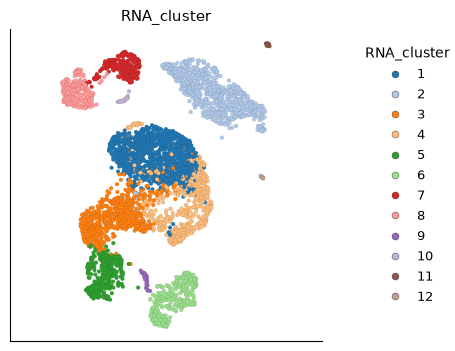

In [4]:
n_clusters = int(
    ds.cells.to_pandas_dataframe(columns=["RNA_leiden_cluster"], key="I")[
        "RNA_leiden_cluster"
    ].nunique()
)
ds.run_clustering(n_clusters=n_clusters)
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_cluster",
    show=False,
).figure

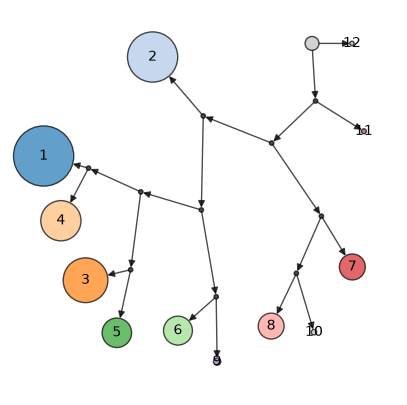

In [5]:
splt.cluster_tree(ds, cluster_key="RNA_cluster", width=1)